In [9]:
import math

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import numpy as np

from lokan import *
from lokan import loKAN
from lokan.utils import ex_round
from lokan.feynman import get_feynman_dataset

In [4]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


In [5]:
N_TRAIN = 1000
N_TEST = 200

In [7]:
def _detect_n_inputs(f, lo_val, hi_val):
    for n in range(1, 20):
        try:
            dummy = torch.rand(2, n) * (hi_val - lo_val) + lo_val
            f(dummy)
            return n
        except Exception:
            continue
    raise RuntimeError('Could not auto-detect n_inputs from feynman lambda')

In [104]:
def make_feynman_dataset(eq_name, n_train=N_TRAIN, n_test=N_TEST, seed=0):
    torch.manual_seed(seed)
    np.random.seed(seed)

    _, _, f, ranges = get_feynman_dataset(eq_name)

    if isinstance(ranges[0], (list, tuple)):
        n_in = len(ranges)
        lo = torch.tensor([r[0] for r in ranges], dtype=torch.float32)
        hi = torch.tensor([r[1] for r in ranges], dtype=torch.float32)
    else:
        lo_val, hi_val = float(ranges[0]), float(ranges[1])
        n_in = _detect_n_inputs(f, lo_val, hi_val)
        lo = torch.full((n_in,), lo_val)
        hi = torch.full((n_in,), hi_val)

    total = n_train + n_test

    def _sample(n):
        x = torch.rand(n, n_in) * (hi - lo) + lo
        y = f(x)
        if y.dim() == 1:
            y = y.unsqueeze(1)
        mask = torch.isfinite(y).squeeze(1)
        return x[mask], y[mask]

    x, y = _sample(total * 5)
    x, y = x[:total], y[:total]

    if x.shape[0] < total:
        raise RuntimeError(f'{eq_name}: could not sample {total} finite points')

    return {
        'train_input': x[:n_train].to(device),
        'train_label': y[:n_train].to(device),
        'test_input':  x[n_train:total].to(device),
        'test_label':  y[n_train:total].to(device),
    }, n_in

In [105]:
def evaluate(model, dataset):
    model.eval()
    with torch.no_grad():
        pred = model(dataset['test_input']).cpu()
    y = dataset['test_label'].cpu()
    mse    = float(torch.mean((pred - y) ** 2))
    ss_res = float(torch.sum((pred - y) ** 2))
    ss_tot = float(torch.sum((y - y.mean()) ** 2))
    rmse   = math.sqrt(mse)
    r2     = 1.0 - ss_res / ss_tot if ss_tot > 1e-12 else float('nan')
    return rmse, r2

I.9.18 (9)

In [136]:
dataset, n_in = make_feynman_dataset('I.9.18', seed=0)

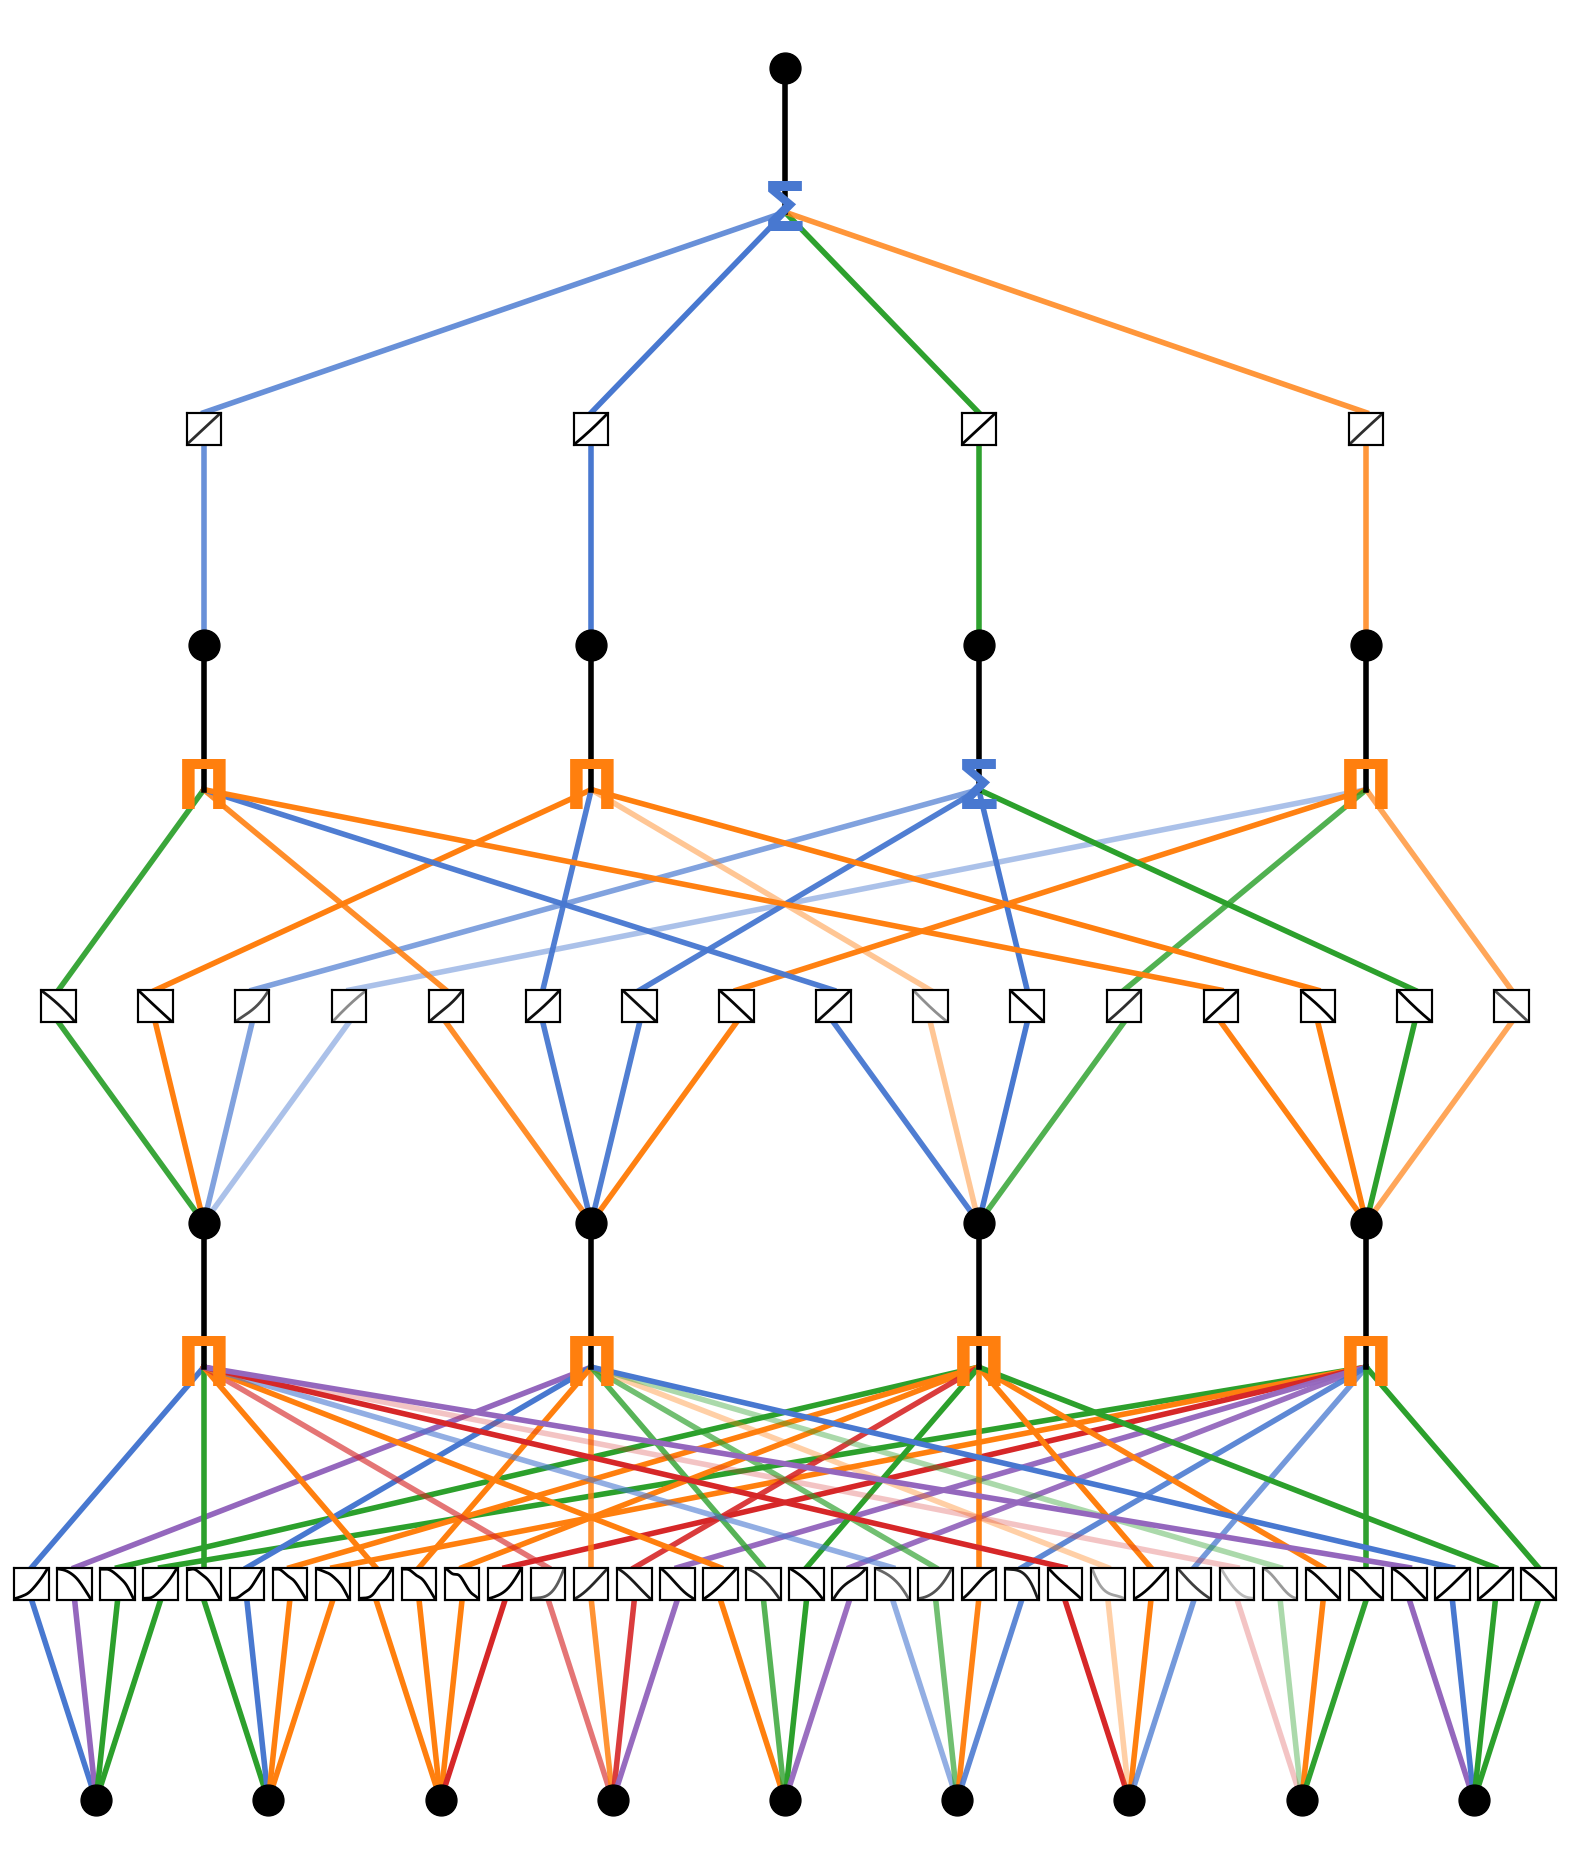

In [137]:
torch.manual_seed(1)
model = LOKAN(width=[n_in, n_in // 2, n_in // 2, 1], grid=5, k=3, 
              seed=1, device=device)
model(dataset['train_input'])
model.plot(scale = 2.0)

In [138]:
history = model.fit(dataset=dataset,
                    lr_start=0.2, lr_end=1e-3, batch_size=64, epochs=120,
                    tau_start=2.0, tau_end=0.1,
                    lamb_ent_ops_start=1e-2, lamb_ent_ops_end=1.0,
                    lamb_l1_acts=1e-10, lamb_ent_acts=1e-10,
                    update_grid=True,
                    # update_grid=False,
                    grid_update_num=10,
                    start_grid_update_epoch=0, stop_grid_update_epoch=None,
                    # refine_schedule=[(20, 5)],
                    verbose=10)

Epoch [  10/120]  train=0.000766  test=0.000740  tau=1.595  λ=0.0142  grid=5
Epoch [  20/120]  train=0.000055  test=0.000048  tau=1.240  λ=0.0209  grid=5
Epoch [  30/120]  train=0.000016  test=0.000040  tau=0.964  λ=0.0307  grid=5
Epoch [  40/120]  train=0.000014  test=0.000023  tau=0.749  λ=0.0452  grid=5
Epoch [  50/120]  train=0.000010  test=0.000018  tau=0.583  λ=0.0666  grid=5
Epoch [  60/120]  train=0.000009  test=0.000017  tau=0.453  λ=0.0981  grid=5
Epoch [  70/120]  train=0.000008  test=0.000016  tau=0.352  λ=0.1444  grid=5
Epoch [  80/120]  train=0.000008  test=0.000014  tau=0.274  λ=0.2127  grid=5
Epoch [  90/120]  train=0.000007  test=0.000014  tau=0.213  λ=0.3132  grid=5
Epoch [ 100/120]  train=0.000007  test=0.000014  tau=0.165  λ=0.4612  grid=5
Epoch [ 110/120]  train=0.000007  test=0.000013  tau=0.129  λ=0.6791  grid=5
Epoch [ 120/120]  train=0.000007  test=0.000013  tau=0.100  λ=1.0000  grid=5


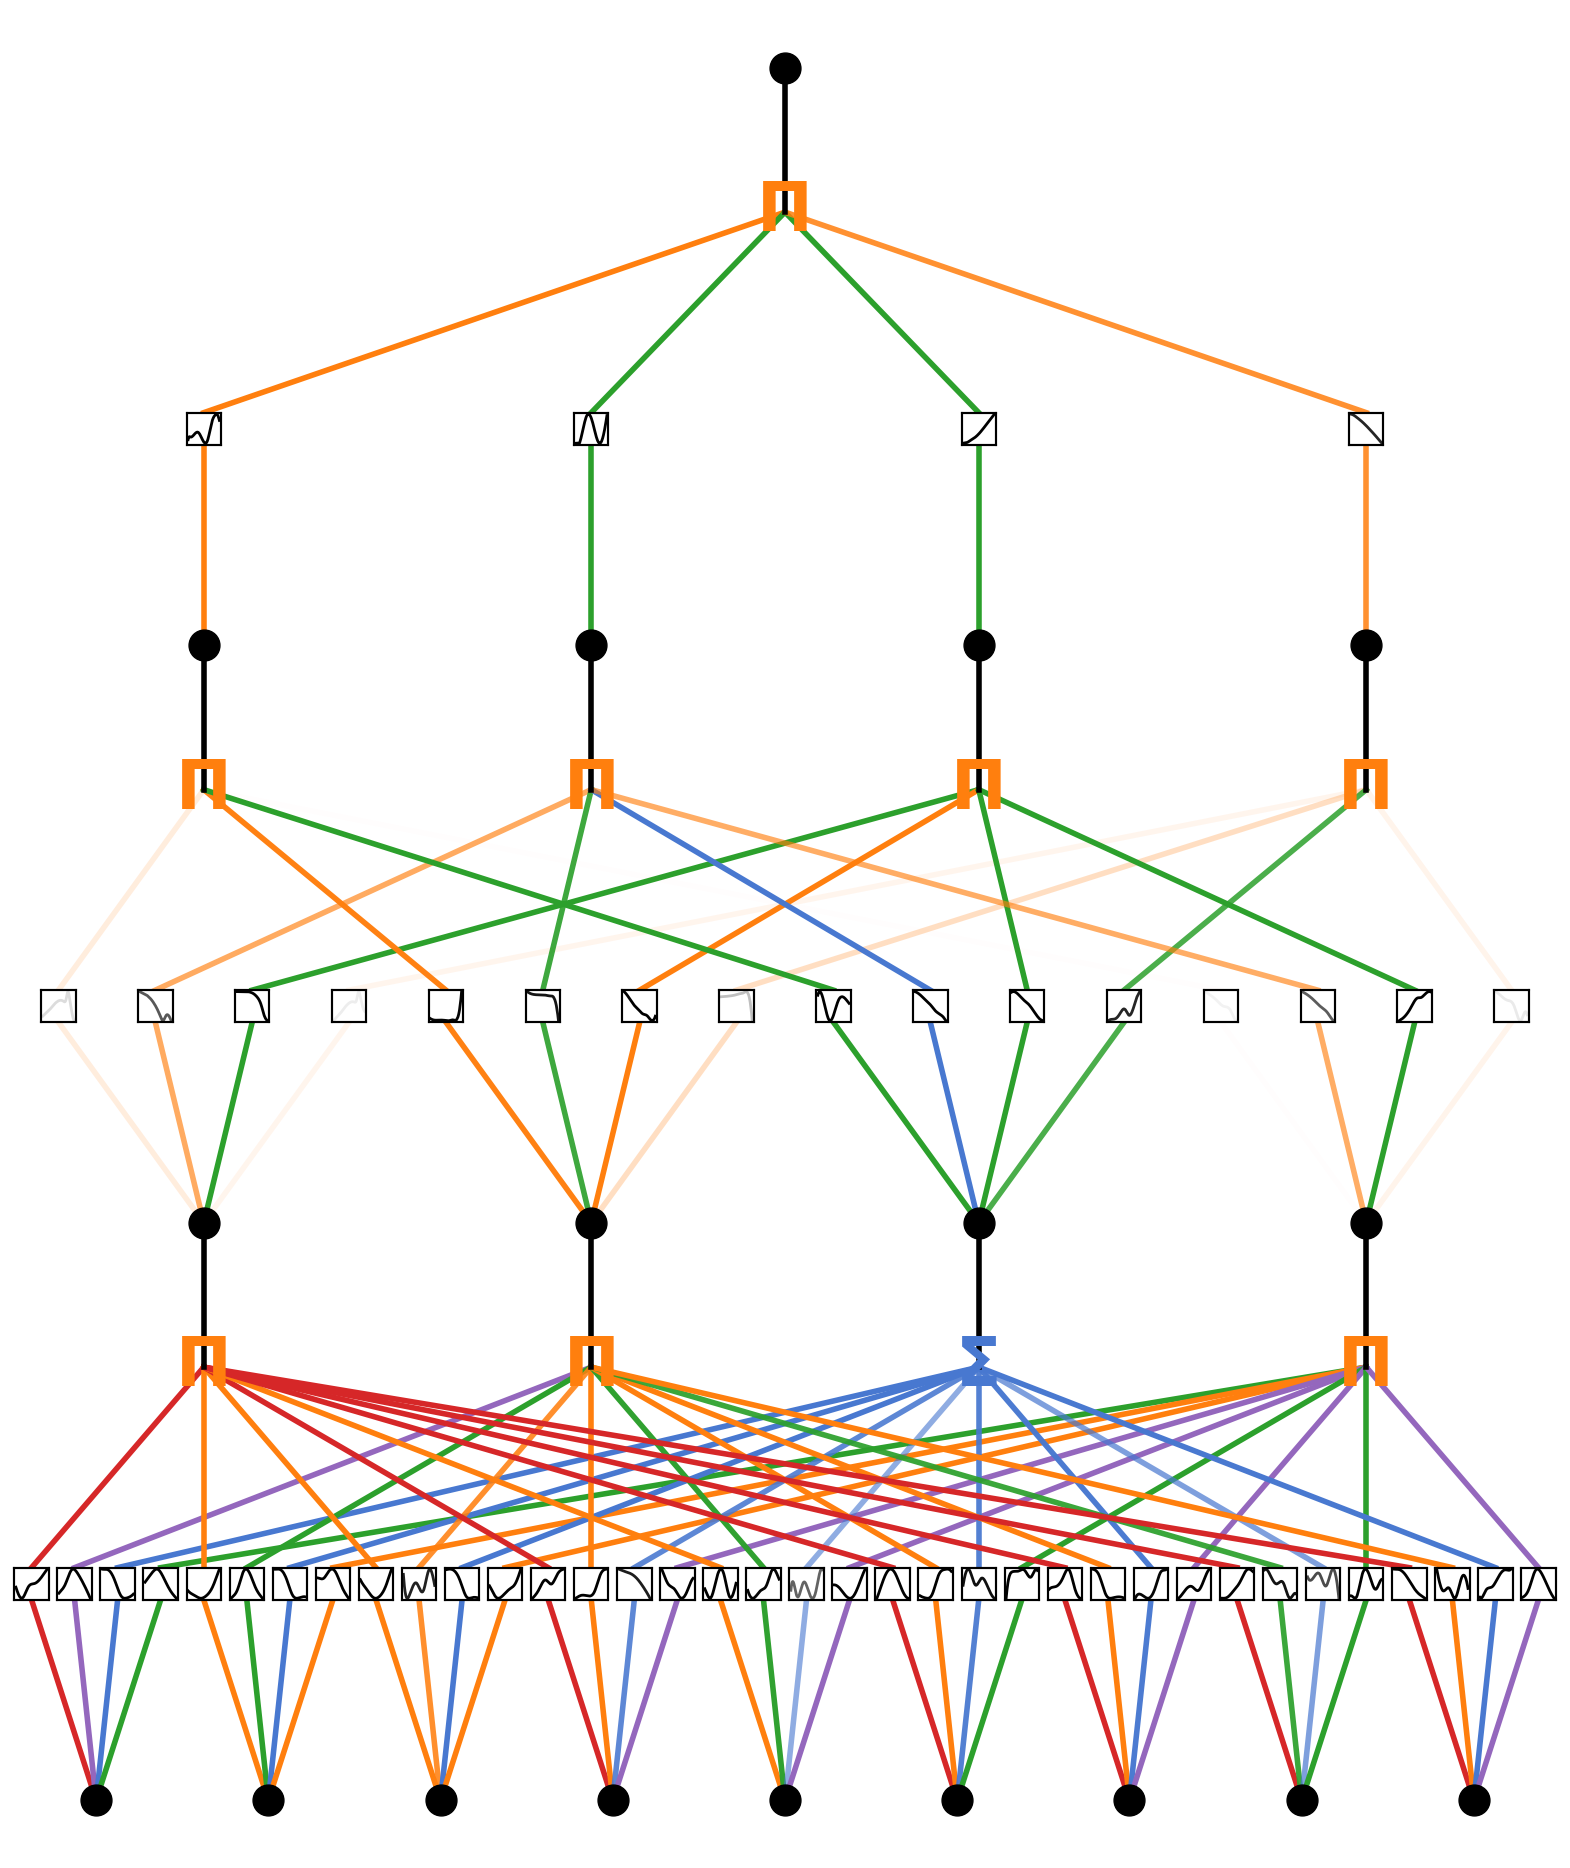

In [140]:
model.plot(scale = 2.0)

In [141]:
evaluate(model, dataset)

(0.00365913973545928, 0.9840284517458142)

I.18.4 (3)

In [87]:
dataset, n_in = make_feynman_dataset('I.18.4', seed=0)

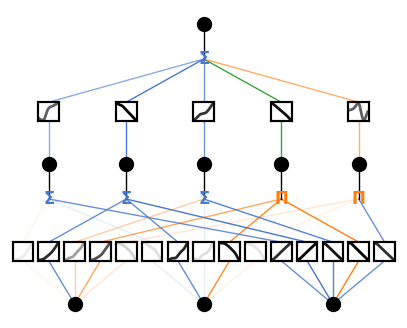

In [94]:
torch.manual_seed(0)
model = LOKAN(width=[n_in, n_in + 2, 1], grid=5, k=3, 
            #   grid_range=[-2.0 * torch.pi, 2.0 * torch.pi],
              seed=0, device=device)
model(dataset['train_input'])
model.plot()

In [95]:
history = model.fit(dataset=dataset,
                    lr_start=0.2, lr_end=1e-3, batch_size=64, epochs=120,
                    tau_start=2.0, tau_end=0.1,
                    lamb_ent_ops_start=1e-2, lamb_ent_ops_end=1.0,
                    lamb_l1_acts=1e-3, lamb_ent_acts=1e-6,
                    update_grid=True,
                    # update_grid=False,
                    grid_update_num=10,
                    start_grid_update_epoch=0, stop_grid_update_epoch=None,
                    # refine_schedule=[(20, 5)],
                    verbose=10)

Epoch [  10/120]  train=0.001551  test=0.000781  tau=1.595  λ=0.0142  grid=5
Epoch [  20/120]  train=0.000617  test=0.000632  tau=1.240  λ=0.0209  grid=5


KeyboardInterrupt: 

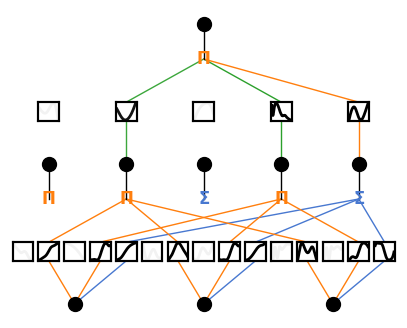

In [ ]:
model.plot()